In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
import sys
import tqdm.auto as tqdm
from scipy.stats import spearmanr, kendalltau
from functools import namedtuple
from joblib import Parallel, delayed

from dti.constants import ACT, PREDICTION, ASSAY
from dti.utils import Method

In [2]:
p = pathlib.Path("../data/hpc-data/")

In [15]:
predictions = list()
for run in tqdm.tqdm(p.iterdir()):
    preds = run / "predictions.csv.gz"
    if not preds.exists():
        continue
    dataset, fold, method, _ = run.name.split("_")
    method = Method.from_string(method)
    if method not in [Method.IC50, Method.ALLSETS, Method.SETS]:
        continue
    fold = int(fold)
    df = pd.read_csv(preds, index_col=0)
    df["method"] = method
    df["fold"] = fold
    df["dataset"] = dataset
    predictions.append(df)
predictions = pd.concat(predictions)

0it [00:00, ?it/s]

In [4]:
predictions

,prediction,target,compound_id,assay_id,method,dataset
0,69.602760,0.824510,692016,4315,Random SetRank,atcc
1,69.676230,0.490454,692594,4315,Random SetRank,atcc
2,69.610210,-0.067132,691600,4315,Random SetRank,atcc
3,69.677880,0.641152,691608,4315,Random SetRank,atcc
4,69.621420,1.112896,692036,4315,Random SetRank,atcc
...,...,...,...,...,...,...
9032,28.229849,0.814030,685880,3959,Assay SetRank,ovcar
9033,27.910284,-0.045444,123127,4125,Assay SetRank,ovcar
9034,28.427858,0.930995,688360,4125,Assay SetRank,ovcar
9035,28.314548,0.229673,692392,4125,Assay SetRank,ovcar


<Axes: xlabel='prediction', ylabel='Count'>

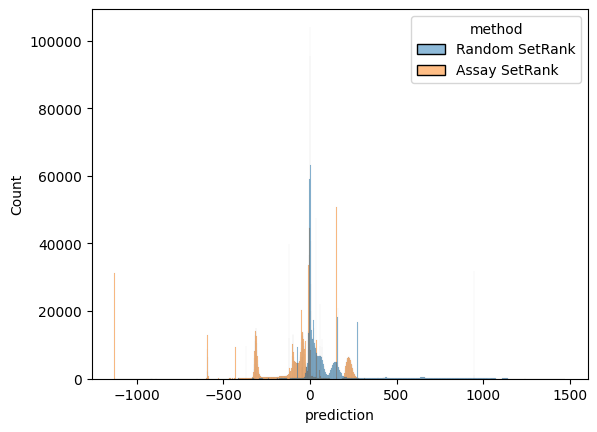

In [11]:
sns.histplot(
    predictions[predictions["method"] != Method.IC50], x=PREDICTION, hue="method"
)

<Axes: xlabel='prediction', ylabel='Density'>

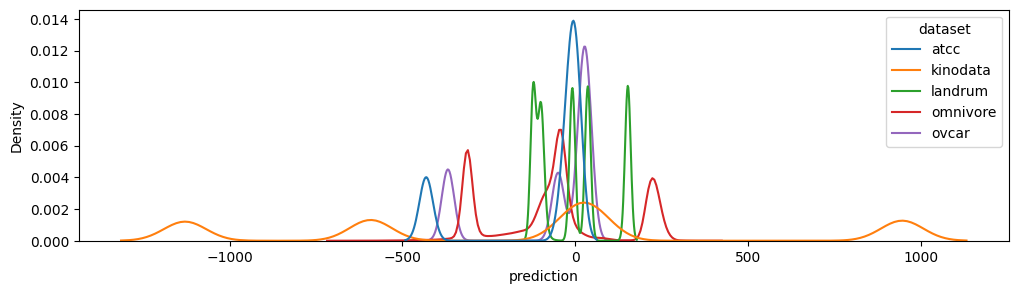

In [14]:
plt.figure(figsize=(12, 3))
sns.kdeplot(
    predictions[predictions["method"] == Method.SETS],
    x=PREDICTION,
    hue="dataset",
    common_norm=False,
)

<Axes: xlabel='prediction', ylabel='Density'>

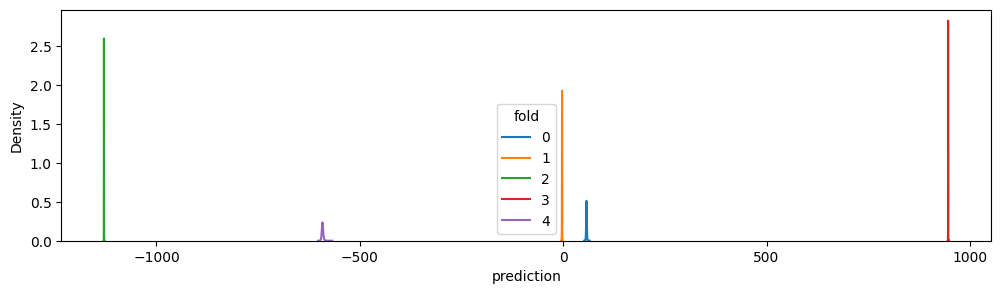

In [17]:
plt.figure(figsize=(12, 3))
sns.kdeplot(
    predictions[
        (predictions["method"] == Method.SETS) & (predictions["dataset"] == "kinodata")
    ],
    x=PREDICTION,
    hue="fold",
    common_norm=False,
    palette="tab10",
)

In [114]:
import numpy as np


def enrichment(pred, truth, fraction):
    """
    Compute the enrichment factor (EF) at a given fraction.

    Parameters:
        pred (array-like): A list or array of predicted scores (higher is better).
        truth (array-like): A numeric list/array (higher means more relevant).
        fraction (float): The fraction (e.g., 0.1 for top 10%) of ranked predictions to consider.

    Returns:
        float: The enrichment factor.
    """
    if not (0 < fraction <= 1):
        raise ValueError("Fraction should be between 0 and 1.")

    pred = np.array(pred)
    truth = np.array(truth)

    # Determine the threshold for actives (top fraction of truth)
    num_total = len(truth)
    num_actives = int(num_total * fraction)

    if num_actives == 0:
        return 0.0  # Avoid division by zero

    # Find threshold for being considered an "active"
    truth_threshold = np.partition(truth, -num_actives)[
        -num_actives
    ]  # nth largest value

    # Convert truth to binary: 1 if in the top fraction, 0 otherwise
    binary_truth = (truth >= truth_threshold).astype(int)

    # Sort indices by descending predicted scores
    sorted_indices = np.argsort(pred)[::-1]

    # Get sorted binary truth values
    sorted_truth = binary_truth[sorted_indices]

    # Number of items in the top `fraction`
    num_top = num_actives  # Same as `int(len(truth) * fraction)`

    # Count actives in the top fraction
    num_actives_top = np.sum(sorted_truth[:num_top])

    # Compute EF
    ef = (num_actives_top / num_top) / (np.mean(binary_truth))
    assert ef >= 0
    return ef if np.mean(binary_truth) > 0 else 0.0  # Avoid division by zero

In [126]:
keys = ["dataset", "assay_id", "method", "fold"]
Row = namedtuple("Row", keys + ["size", "spearman", "kendall", "ef_1", "ef_5", "ef_10"])


def proc(args):
    feats, group = args
    if group["target"].nunique() <= 1:
        # print("boring assay:", feats, file=sys.stderr)
        return None
    kt = kendalltau(group[PREDICTION], group["target"]).statistic
    sr = spearmanr(group[PREDICTION], group["target"]).statistic
    ef_1 = enrichment(group[PREDICTION].values, group["target"].values, 0.01)
    ef_5 = enrichment(group[PREDICTION].values, group["target"].values, 0.05)
    ef_10 = enrichment(group[PREDICTION].values, group["target"].values, 0.1)

    return Row(*(list(feats) + [len(group), sr, kt, ef_1, ef_5, ef_10]))


performance = Parallel(n_jobs=8)(
    map(delayed(proc), tqdm.tqdm(predictions.groupby(keys)))
)
performance = pd.DataFrame([p for p in performance if p is not None])

  0%|          | 0/205707 [00:00<?, ?it/s]

/tmp/ipykernel_144764/3174736771.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/tmp/ipykernel_144764/3174736771.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/tmp/ipykernel_144764/3174736771.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/tmp/ipykernel_144764/3174736771.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/tmp/ipykernel_144764/3174736771.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/tmp/ipykernel_144764/3174736771.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/tmp/ipykernel_144764/3174736771.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/tmp/ipykernel_144764/3174736771.py:11: ConstantInputWarning: 

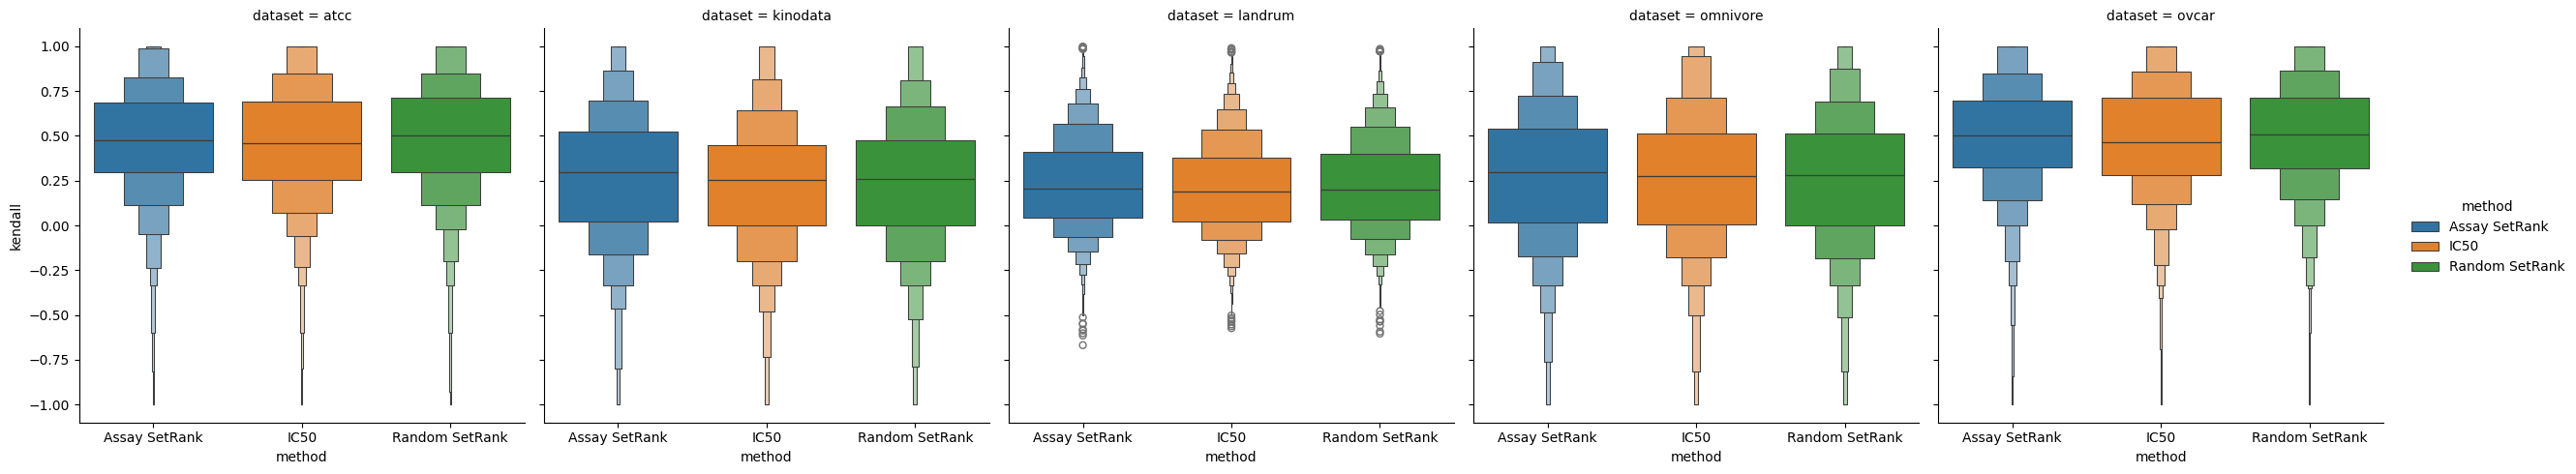

In [127]:
sns.catplot(
    performance, y="kendall", x="method", hue="method", col="dataset", kind="boxen"
)

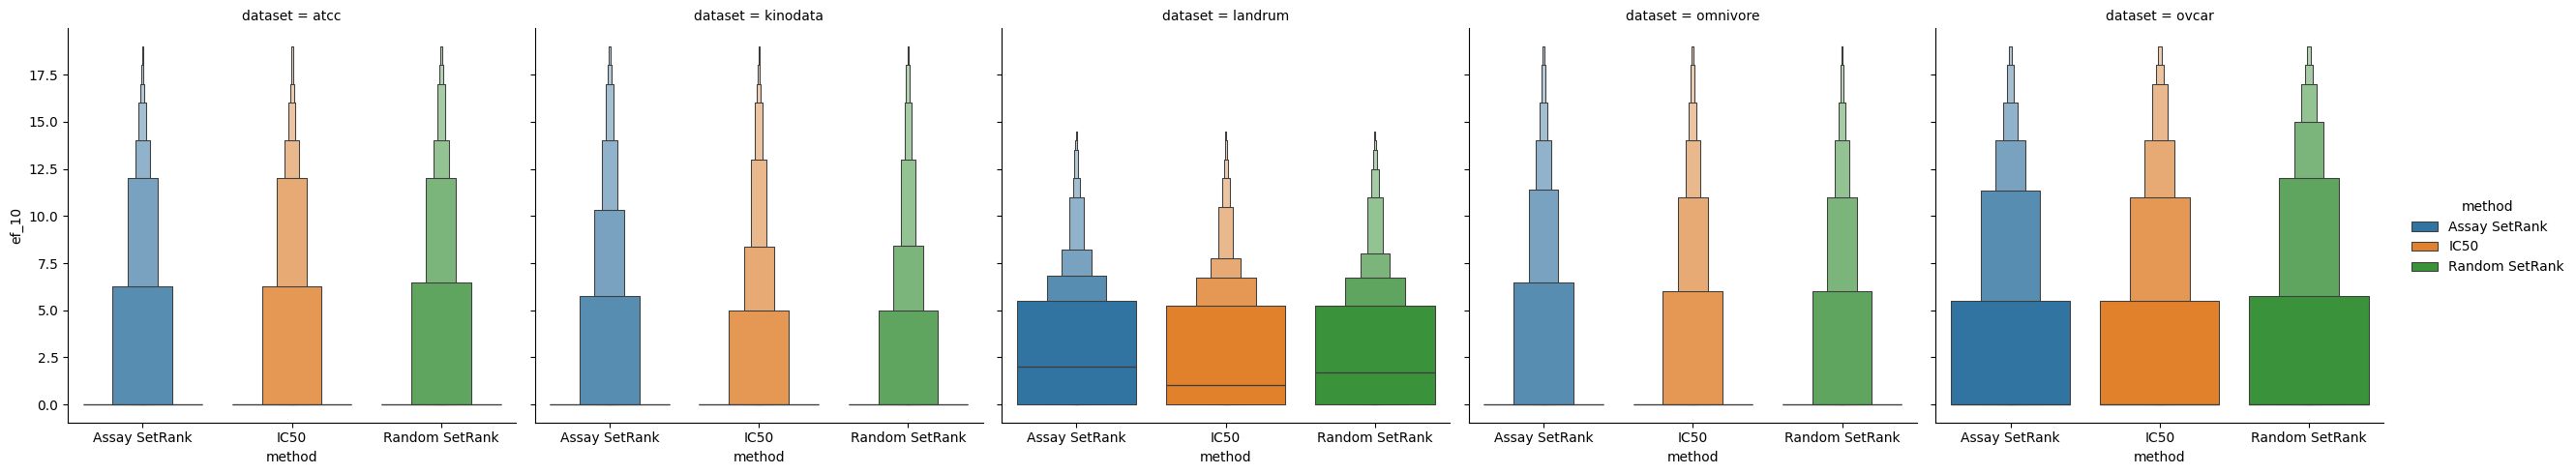

In [128]:
sns.catplot(
    performance, y="ef_10", x="method", hue="method", col="dataset", kind="boxen"
)

/home/michael/Code/hodge-dti/.venv/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


<Axes: xlabel='kendall', ylabel='size'>

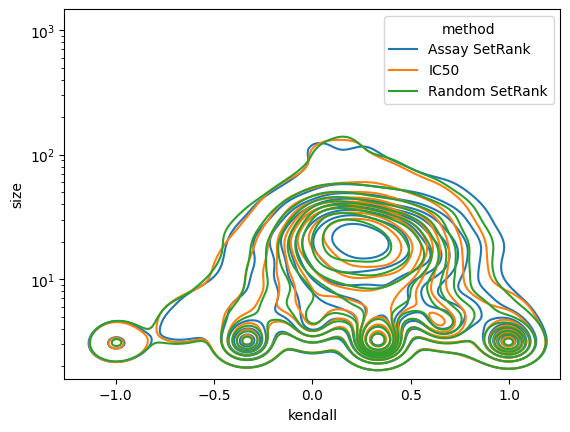

In [41]:
sns.kdeplot(
    performance[performance["dataset"] == "kinodata"],
    x="kendall",
    y="size",
    log_scale=(False, True),
    s=2,
    hue="method",
)

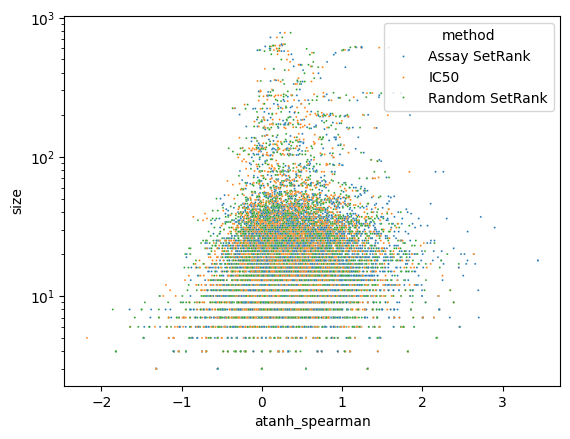

In [48]:
performance["atanh_spearman"] = np.atanh(performance["spearman"].values)
# performance = performance[]
sns.scatterplot(
    performance[
        (performance["dataset"] == "kinodata")
        & (performance["atanh_spearman"].abs() < 10)
    ],
    x="atanh_spearman",
    y="size",
    hue="method",
    s=2,
)
plt.yscale("log")

<Axes: xlabel='atanh_spearman', ylabel='size'>

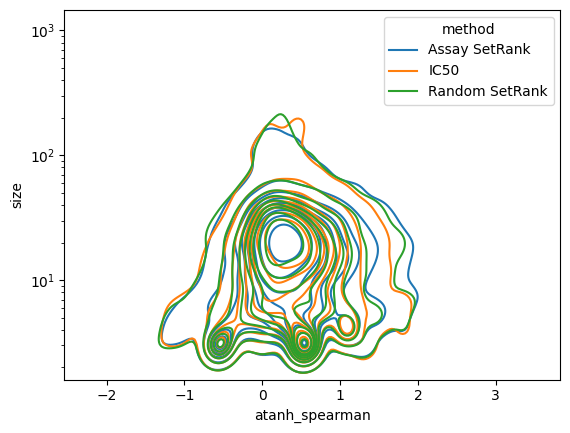

In [49]:
sns.kdeplot(
    performance[performance["dataset"] == "kinodata"],
    x="atanh_spearman",
    y="size",
    hue="method",
    log_scale=(False, True),
)

In [129]:
keys = ["dataset", "method", "fold"]
Row = namedtuple("Row", keys + ["size", "spearman", "kendall", "ef_1", "ef_5", "ef_10"])
rows = list()
for feats, group in tqdm.tqdm(performance.groupby(keys)):
    if len(group) <= 3:
        continue
    weights = group["size"] - 3
    sr = (
        np.atanh(np.clip(group["spearman"], 1e-7 - 1, 1 - 1e-7)) * weights
    ).sum() / weights.sum()
    n = group["size"].sum()
    kt = (group["kendall"] * group["size"]).sum() / n
    ef10 = (group["ef_10"] * group["size"]).sum() / n
    ef5 = (group["ef_5"] * group["size"]).sum() / n
    ef1 = (group["ef_1"] * group["size"]).sum() / n
    rows.append(Row(*(list(feats) + [n, sr, kt, ef1, ef5, ef10])))
overall_perf = pd.DataFrame(rows)

  0%|          | 0/75 [00:00<?, ?it/s]

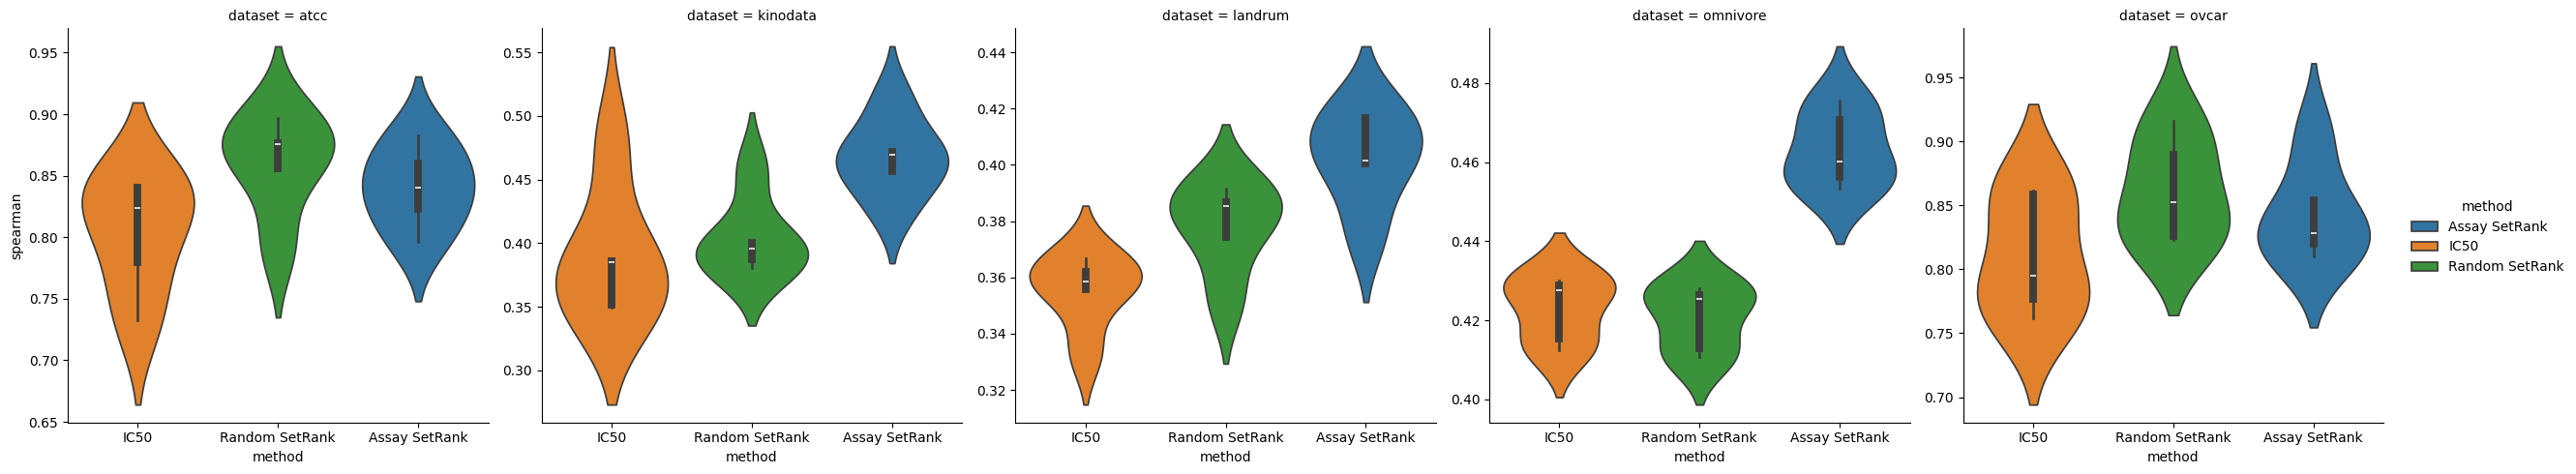

In [95]:
hue_order = ["IC50", "Random SetRank", "Assay SetRank"]
sns.catplot(
    overall_perf,
    y="spearman",
    col="dataset",
    x="method",
    hue="method",
    kind="violin",
    sharey=False,
    order=hue_order,
)

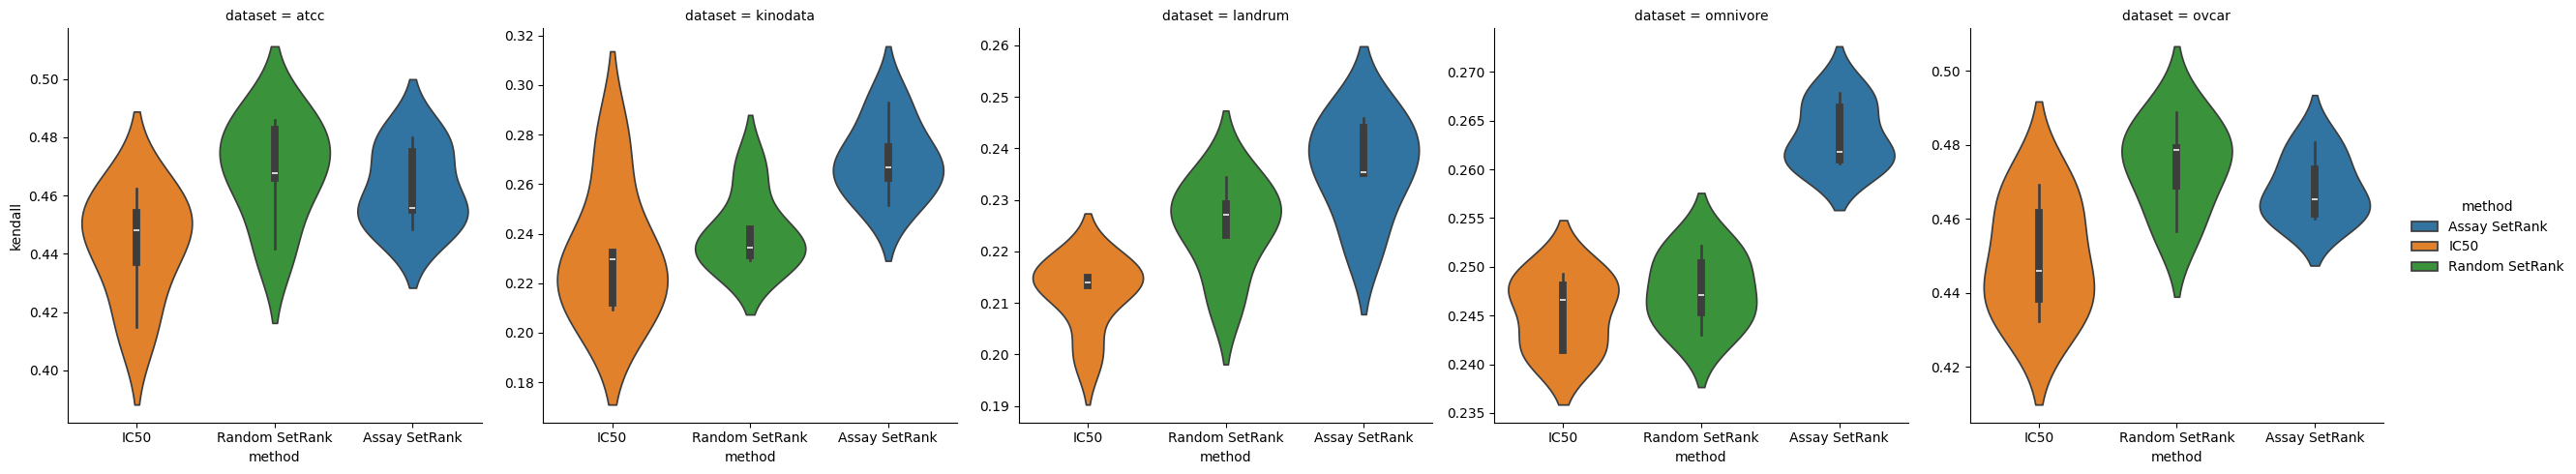

In [96]:
sns.catplot(
    overall_perf,
    y="kendall",
    col="dataset",
    hue="method",
    x="method",
    kind="violin",
    sharey=False,
    order=hue_order,
)

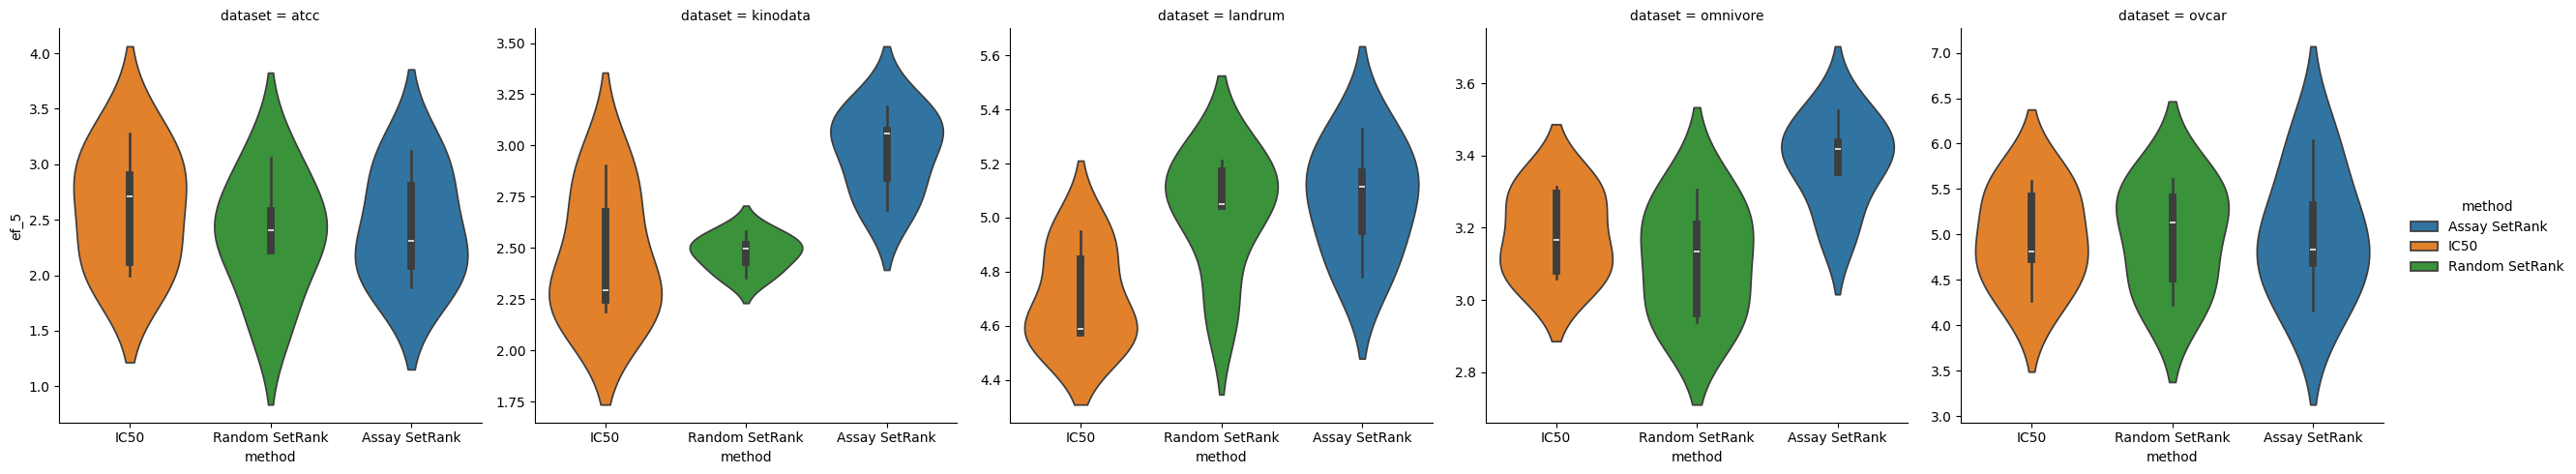

In [130]:
sns.catplot(
    overall_perf,
    y="ef_5",
    col="dataset",
    hue="method",
    x="method",
    kind="violin",
    sharey=False,
    order=hue_order,
)

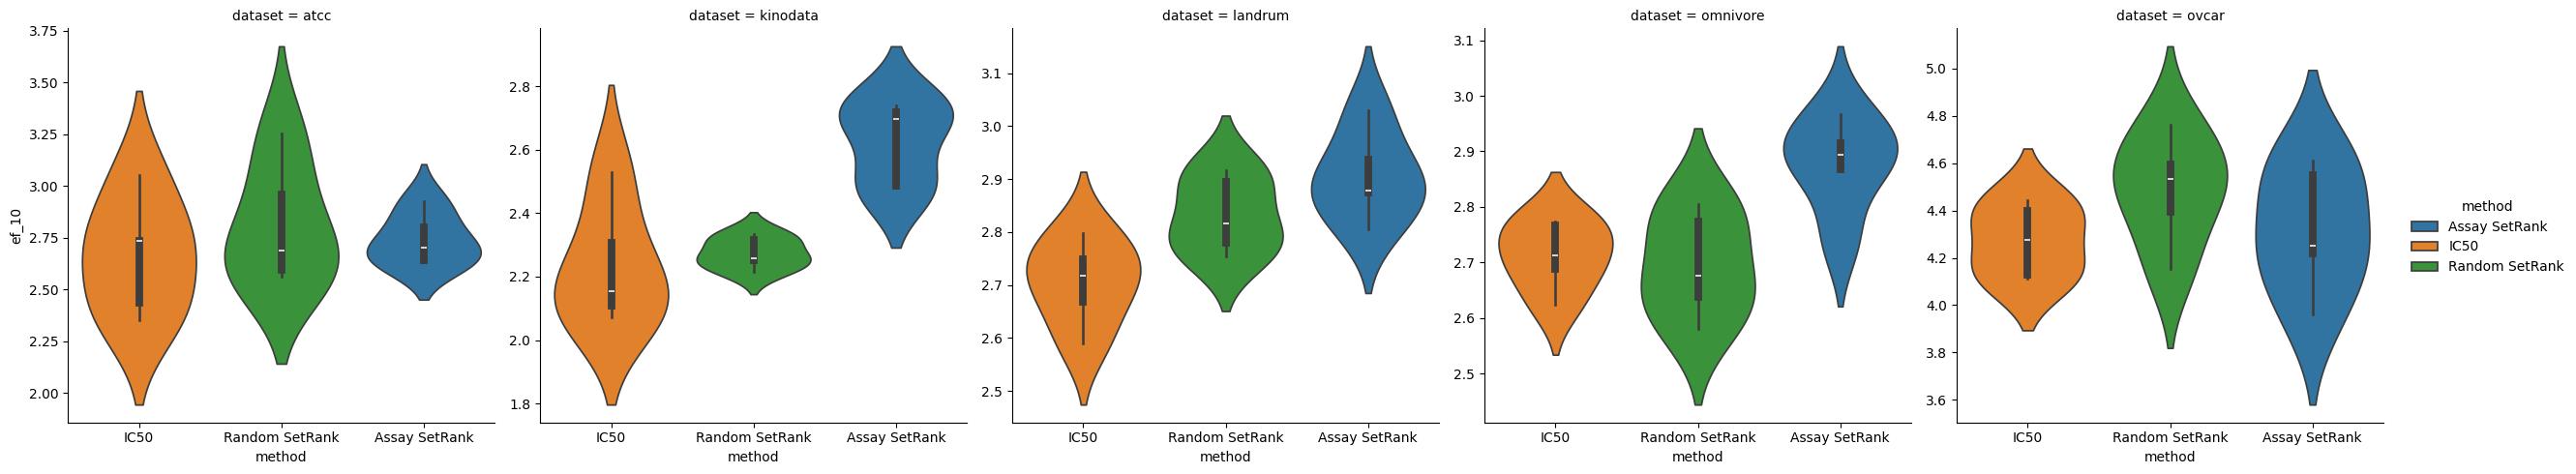

In [123]:
sns.catplot(
    overall_perf,
    y="ef_10",
    col="dataset",
    hue="method",
    x="method",
    kind="violin",
    sharey=False,
    order=hue_order,
)